In [83]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df= pd.read_csv('../titanic_data_updated.csv')
df.head(4)
display(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [85]:
df1= df.copy()
df1.drop(['PassengerId' , 'Name' , 'Ticket'] , axis=1 , inplace=True) #axis =1  culumn 
df1.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S


In [99]:
from sklearn.model_selection import train_test_split #pip install scikit-learn
from sklearn.impute import SimpleImputer

y= df1['Survived']  # target culumn
X = df1[['Pclass' , 'Sex' , 'Age' , 'SibSp' , 'Parch' , 'Fare' , 'Embarked']] # feature culumns


X_train , X_test , y_train ,y_test = train_test_split(X,y , test_size=0.2 , random_state = 42)

display(len(X_train))
display(len(X_test))


712

179

Normal distribution        

# Outliners via Z score #

A z-score measures how many standard deviations a value is from the mean.

Formula: z = (x − μ) / σ

where x is the value, μ is the mean, and σ is the standard deviation. 

A z-score of 0 means exactly average; +2 means 2 SDs above; −1 means 1 SD below. 
 
 -1μ to +1μ covers 68% data 

-2μ to +2μ covers 95% data

-3μ to +3μ covers 99.7% data

beyond this is outliners  

z score works best on normal distribution data.

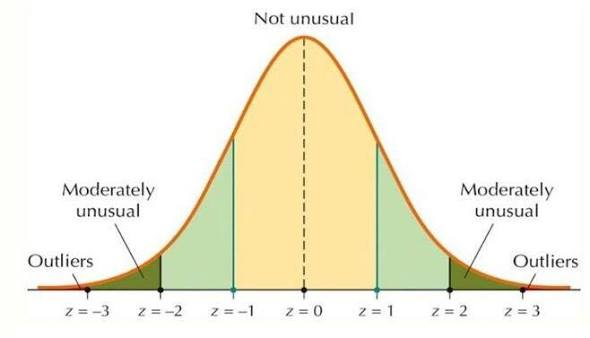

In [87]:
from IPython.display import Image, display
display(Image(filename='images.jpeg'))

In [88]:
X_train.describe()

,Age,SibSp,Parch,Fare
count,572.000000,712.000000,712.000000,712.000000
mean,29.498846,0.553371,0.379213,32.586276
std,14.500059,1.176404,0.791669,51.969529
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.925000
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,30.500000
max,80.000000,8.000000,6.000000,512.329200


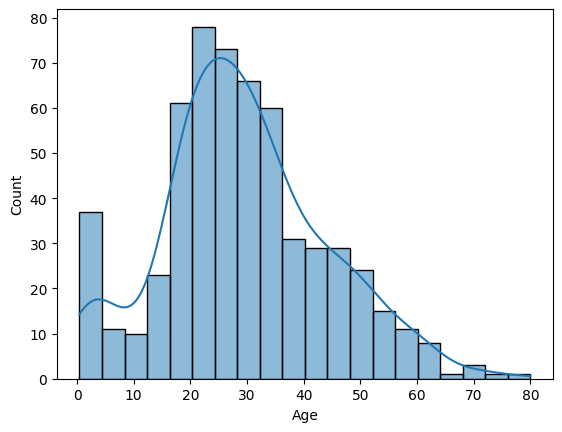

In [89]:
sns.histplot(data=X_train['Age'] , kde=True)
plt.show()

In [101]:
mean= X_train['Age'].mean()
std = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age']-mean) /std

outliners = X_train [abs(X_train['Z_score']) > 3]

print(len(outliners)) 

print(outliners)


2
    Pclass   Sex   Age  SibSp  Parch    Fare Embarked   Z_score
630  first  male  80.0      0      0  30.000        S  3.482824
851  third  male  74.0      0      0   7.775        S  3.069033


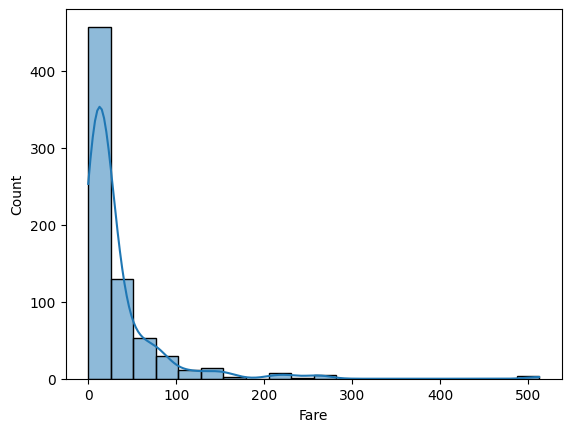

In [91]:
sns.histplot(data=X_train['Fare'] , kde=True , bins=20)
plt.show()

In [92]:
mean_fare= X_train['Fare'].mean()
std_fare = X_train['Fare'].std()

X_train['Z_score_fare'] = (X_train['Fare']-mean_fare) /std_fare

outliners_fare = X_train [abs(X_train['Z_score_fare']) > 3]

print(len(outliners_fare)) 

print(outliners_fare)


17
    Pclass     Sex   Age  SibSp  Parch      Fare Embarked   Z_score  \
118  first    male  24.0      0      1  247.5208        C -0.379229   
716  first  female  38.0      0      0  227.5250        C  0.586284   
377  first    male  27.0      0      2  211.5000        C -0.172334   
742  first  female  21.0      2      2  262.3750        C -0.586125   
380  first  female  42.0      0      0  227.5250        C  0.862145   
779  first  female  43.0      0      1  211.3375        S  0.931110   
730  first  female  29.0      0      0  211.3375        S -0.034403   
88   first  female  23.0      3      2  263.0000        S -0.448194   
341  first  female  24.0      3      2  263.0000        S -0.379229   
557  first    male   NaN      0      0  227.5250        C       NaN   
737  first    male  35.0      0      0  512.3292        C  0.379388   
679  first    male  36.0      0      1  512.3292        C  0.448354   
438  first    male  64.0      1      4  263.0000        S  2.379380   
689

Outlines via IQR

The IQR tells you the range of the middle 50% of your data. It ignores extreme values (outliers), so it’s a robust measure of spread.

IQR=Q3-Q1


Q1 (First Quartile): 25% of data falls below this value
Q3 (Third Quartile): 75% of data falls below this value

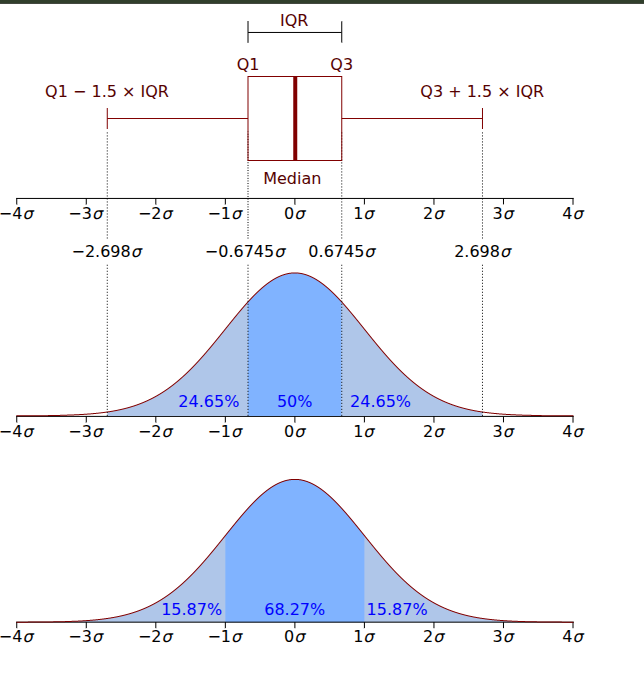

In [93]:
from IPython.display import Image, display
display(Image(filename='IQR_Z_SCore.png'))

In [94]:
age_Q1=X_train['Age'].quantile(0.25)

age_Q3=X_train['Age'].quantile(0.75)

age_IQR= age_Q3 - age_Q1

age_minimum = age_Q1-1.5*age_IQR

age_maximum = age_Q3 + 1.5*age_IQR

print(age_minimum)
print(age_maximum)



-4.5
63.5


In [95]:
age_outliners= X_train[(X_train['Age']< age_minimum) | (X_train['Age'] > age_maximum)]

display(age_outliners)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Z_score,Z_score_fare
456,first,male,65.0,0,0,26.550,S,2.448345,-0.116150
116,third,male,70.5,0,0,7.750,Q,2.827654,-0.477901
745,first,male,70.0,1,1,71.000,S,2.793172,0.739159
630,first,male,80.0,0,0,30.000,S,3.482824,-0.049765
851,third,male,74.0,0,0,7.775,S,3.069033,-0.477420
438,first,male,64.0,1,4,263.000,S,2.379380,4.433631
672,second,male,70.0,0,0,10.500,S,2.793172,-0.424985


In [96]:

fare_Q1=X_train['Fare'].quantile(0.25)

fare_Q3=X_train['Fare'].quantile(0.75)

fare_IQR= fare_Q3 - fare_Q1

fare_minimum = fare_Q1-1.5*fare_IQR

fare_maximum = fare_Q3 + 1.5*fare_IQR

print(fare_minimum)
print(fare_maximum)



-25.937499999999996
64.3625


In [97]:
Fare_outliners= X_train[(X_train['Fare']< fare_minimum) | (X_train['Fare'] > fare_maximum)]

display(Fare_outliners)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Z_score,Z_score_fare
118,first,male,24.0,0,1,247.5208,C,-0.379229,4.135780
486,first,female,35.0,1,0,90.0000,S,0.379388,1.104757
716,first,female,38.0,0,0,227.5250,C,0.586284,3.751020
390,first,male,36.0,1,2,120.0000,S,0.448354,1.682019
377,first,male,27.0,0,2,211.5000,C,-0.172334,3.442666
...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,C,-0.172334,0.849400
385,second,male,18.0,0,0,73.5000,S,-0.793021,0.787264
700,first,female,18.0,1,0,227.5250,C,-0.793021,3.751020
435,first,female,14.0,1,2,120.0000,S,-1.068882,1.682019


Z_Score vs IQR 

Z_Score is mean based and sensitive to outliers, while IQR is robust and not affected by outliers.

ZScore is suitable for normally distributed data, 

while IQR can be used for any distribution (skewed or not).

In [107]:
#for age outlines Z_score method is better ( normally distributed data)

display(len(X_train))
X_train_final= X_train [abs(X_train['Z_score']) <= 3]
outlin= X_train [abs(X_train['Z_score']) > 3]

print(len(outlin))
display(len(X_train_final))
display(X_train_final.head(4))


712

2


570

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Z_score
331,first,male,45.5,0,0,28.5000,S,1.103523
733,second,male,23.0,0,0,13.0000,S,-0.448194
382,third,male,32.0,0,0,7.9250,S,0.172493
704,third,male,26.0,1,0,7.8542,S,-0.241299
